# ทดสอบและทำนายผลตัวอักษรไทย (Inference - Top-1)
### โครงงานจำแนกตัวอักษรและตัวเลขภาษาไทย 72 คลาส ด้วย ResNet-18


In [1]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18
import torchvision.transforms.functional as TF

plt.rcParams['font.family'] = 'Tahoma'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 1. โครงสร้าง ResNet-18 (Transfer Learning 72 คลาส)
def build_model(num_classes=72):
    model = resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

# 2. แปลงรหัสคลาส (TIS-620) เป็นตัวอักษรภาษาไทย
def get_thai_char(c):
    try:
        return bytes([int(c)]).decode('tis-620')
    except Exception:
        return str(c)

# 3. ฟังก์ชันโหลดรูปภาพรองรับ GIF, PNG, JPG, BMP และจัดการพื้นหลังโปร่งใส (Transparency / Alpha)
def load_image(img_path):
    img = Image.open(img_path)
    if hasattr(img, 'is_animated') and img.is_animated:
        img.seek(0)
    if img.mode in ('RGBA', 'LA') or (img.mode == 'P' and 'transparency' in img.info):
        img = img.convert('RGBA')
        bg = Image.new('RGBA', img.size, (255, 255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        return bg.convert('RGB')
    return img.convert('RGB')

# 4. โหลดโมเดล model.pt
checkpoint = torch.load('model.pt', map_location=device)
sd = checkpoint.get('model_state_dict', checkpoint)

classes = [str(c) for c in checkpoint.get('classes', [str(i) for i in range(161, 250)])]
idx_to_class = {i: str(c) for i, c in enumerate(classes)}
classes_str = set(classes)

model = build_model(num_classes=len(classes))
model.load_state_dict({k.replace('backbone.', ''): v for k, v in sd.items()})
model = model.to(device)
model.eval()

# 5. Data Transform (64x64)
img_size = checkpoint.get('img_size', 64)
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print(f'โหลดโมเดลสำเร็จ! (Image Size: {img_size}x{img_size}, Classes: {len(classes)})')


Using device: cuda:0
โหลดโมเดลสำเร็จ! (Image Size: 64x64, Classes: 72)


## 1. ฟังก์ชันทำนายภาพเดี่ยว (Single Image Prediction)


ไฟล์: 161_1.png -> ตัวอักษร: ก | รหัสคลาส: 161 | ความมั่นใจ: 99.98%


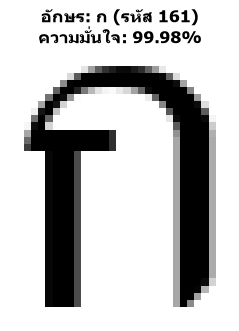

In [2]:
def predict_image(img_path, show=True):
    if not os.path.exists(img_path):
        print(f'ไม่พบไฟล์: {img_path}')
        return None
        
    img = load_image(img_path)
    tensors = [
        transform(img.rotate(angle, fillcolor=(255, 255, 255), resample=Image.BILINEAR)).unsqueeze(0).to(device)
        for angle in [-5, 0, 5]
    ]
    batch_x = torch.cat(tensors, dim=0)
    
    with torch.no_grad():
        probs = torch.softmax(model(batch_x), dim=1).mean(dim=0)
        
    best_idx = probs.argmax().item()
    code = str(idx_to_class[best_idx])
    confidence = probs[best_idx].item() * 100
    char = get_thai_char(code)
    
    print(f'ไฟล์: {os.path.basename(img_path)} -> ตัวอักษร: {char} | รหัสคลาส: {code} | ความมั่นใจ: {confidence:.2f}%')
    
    if show:
        plt.figure(figsize=(3.5, 3.5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'อักษร: {char} (รหัส {code})\nความมั่นใจ: {confidence:.2f}%', fontsize=12, fontweight='bold')
        plt.show()
        
    return {'code': code, 'char': char, 'confidence': confidence}

# ตัวอย่างทดสอบภาพเดี่ยว
sample_img = 'test/161_1.png'
if os.path.exists(sample_img):
    predict_image(sample_img)


## 2. ทำนายผลจากไฟล์ test.csv / test.xlsx และส่งออกไฟล์ out.csv


In [3]:
# ==========================================================
# รองรับ test.csv / test.xlsx ทุกรูปแบบที่อาจารย์อาจส่งมา
# ==========================================================
def load_table_file(file_path):
    ext = os.path.splitext(file_path)[1].lower()
    if ext in (('.xlsx', '.xls')):
        try:
            df = pd.read_excel(file_path)
        except ImportError:
            print("[INFO] กำลังติดตั้ง openpyxl เพื่ออ่านไฟล์ Excel...")
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
            df = pd.read_excel(file_path)
    else:
        df = None
        for enc in ['utf-8', 'utf-8-sig', 'tis-620', 'cp874', 'latin1']:
            try:
                temp_df = pd.read_csv(file_path, encoding=enc)
                first_col = str(temp_df.columns[0])
                if ';' in first_col:
                    temp_df = pd.read_csv(file_path, sep=';', encoding=enc)
                elif '\t' in first_col:
                    temp_df = pd.read_csv(file_path, sep='\t', encoding=enc)
                df = temp_df
                break
            except Exception:
                continue
        if df is None:
            df = pd.read_csv(file_path)

    # ดักกรณีไฟล์ไม่มี Header (แถวแรกเป็นชื่อรูปเลย เช่น 001.png)
    first_col_name = str(df.columns[0]).lower().strip()
    image_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.webp', '.gif', '.tiff', '.tif')
    if any(first_col_name.endswith(e) for e in image_exts):
        if ext in ('.xlsx', '.xls'):
            df = pd.read_excel(file_path, header=None)
        else:
            df = pd.read_csv(file_path, header=None)
        df.columns = ['id'] + [f'col_{i}' for i in range(1, len(df.columns))]

    return df

def find_image_column(df, img_dir):
    # 1. เช็คจากชื่อหัวตารางยอดนิยม
    priority_names = ['id', 'filename', 'file_name', 'image', 'img', 'image_id', 'name', 'path', 'file']
    for p in priority_names:
        for col in df.columns:
            if str(col).lower().strip() == p:
                return col

    # 2. ถ้าไม่ตรง ให้สแกนดูว่าคอลัมน์ไหนมีค่าตรงกับไฟล์ในโฟลเดอร์รูปภาพมากที่สุด
    if os.path.exists(img_dir):
        files_in_dir = set(os.listdir(img_dir))
        files_no_ext = {os.path.splitext(f)[0] for f in files_in_dir}
        best_col = df.columns[0]
        max_matches = -1

        for col in df.columns:
            sample_vals = df[col].dropna().astype(str).str.strip().head(30)
            matches = 0
            for val in sample_vals:
                base_name = os.path.basename(val)
                raw_name = os.path.splitext(base_name)[0]
                if base_name in files_in_dir or raw_name in files_no_ext:
                    matches += 1
            if matches > max_matches:
                max_matches = matches
                best_col = col

        if max_matches > 0:
            return best_col

    return df.columns[0]

def predict_from_csv(csv_path='test/test.csv', img_dir='test', output_csv='out.csv', use_tta=True):
    # ค้นหาไฟล์ตารางอัตโนมัติ (.csv / .xlsx / .xls)
    if not os.path.exists(csv_path):
        base, _ = os.path.splitext(csv_path)
        candidates = [
            csv_path,
            'test/test.csv', 'test.csv',
            'test/test.xlsx', 'test.xlsx',
            'test/test.xls', 'test.xls',
            f'{base}.csv', f'{base}.xlsx', f'{base}.xls'
        ]
        for c in candidates:
            if os.path.exists(c):
                csv_path = c
                break
        else:
            print(f'[ERROR] ไม่พบไฟล์รายการทดสอบ: {csv_path} (หรือ test.csv / test.xlsx)')
            return None

    if not os.path.exists(img_dir):
        img_dir = os.path.dirname(csv_path) or 'test'

    print(f'[INFO] กำลังอ่านข้อมูลจาก: {csv_path}')
    test_df = load_table_file(csv_path)

    # ค้นหาคอลัมน์รูปภาพอัตโนมัติ
    id_col = find_image_column(test_df, img_dir)
    print(f'[INFO] ตรวจพบคอลัมน์ระบุรูปภาพ: "{id_col}"')

    predictions = []
    labeled_count = 0
    correct_count = 0
    valid_exts = ['', '.png', '.jpg', '.jpeg', '.bmp', '.webp', '.tiff', '.tif', '.gif',
                  '.PNG', '.JPG', '.JPEG', '.BMP', '.WEBP', '.TIFF', '.GIF']

    with torch.no_grad():
        for img_id in test_df[id_col]:
            raw_str = str(img_id).strip()
            # ตัด path ทิ้ง เผื่อระบุมาเป็นโฟลเดอร์ เช่น test/img_01.png
            base_name = os.path.basename(raw_str)
            raw_name, raw_ext = os.path.splitext(base_name)

            # จัดการกรณี Excel อ่านเลขจำนวนเต็มเป็น float (101.0 -> 101)
            if raw_name.endswith('.0') and not os.path.exists(os.path.join(img_dir, base_name)):
                clean_name = raw_name[:-2]
            else:
                clean_name = raw_name

            # ค้นหาไฟล์รูปภาพ
            img_path = None
            search_probes = [base_name, clean_name, raw_name]
            for probe in search_probes:
                for ext in valid_exts:
                    p = os.path.join(img_dir, f'{probe}{ext}')
                    if os.path.exists(p) and os.path.isfile(p):
                        img_path = p
                        break
                if img_path:
                    break

            if img_path and os.path.exists(img_path):
                # ตรวจสอบกรณีซ่อนเฉลยไว้ในชื่อ
                prefix = clean_name.split('_')[0]
                true_code = prefix if prefix in classes_str else None

                img = load_image(img_path)
                if use_tta:
                    tensors = [
                        transform(img.rotate(angle, fillcolor=(255, 255, 255), resample=Image.BILINEAR)).unsqueeze(0).to(device)
                        for angle in [-5, 0, 5]
                    ]
                    probs = torch.softmax(model(torch.cat(tensors, dim=0)), dim=1).mean(dim=0, keepdim=True)
                else:
                    tensor = transform(img).unsqueeze(0).to(device)
                    probs = torch.softmax(model(tensor), dim=1)

                pred_idx = probs.argmax(dim=1).item()
                predicted_code = str(idx_to_class[pred_idx])
                label_val = int(predicted_code) if predicted_code.isdigit() else predicted_code
                predictions.append(label_val)

                if true_code is not None:
                    labeled_count += 1
                    if str(label_val) == str(true_code):
                        correct_count += 1
            else:
                predictions.append(None)

    # สร้างผลลัพธ์ out.csv (รักษาคอลัมน์ id เดิมไว้เสมอ)
    out_df = pd.DataFrame({'id': test_df[id_col], 'label': predictions})
    out_csv_path = 'out.csv'
    out_df.to_csv(out_csv_path, index=False)

    # แสดงผลสรุป
    if labeled_count > 0:
        acc = (correct_count / labeled_count) * 100
        print(f'[EVAL] Accuracy: {acc:.2f}% (ถูกต้อง {correct_count:,}/{labeled_count:,} ภาพ)')
    print(f"[OK] บันทึกผลลัพธ์ลง '{out_csv_path}' (CSV) เรียบร้อย ({len(predictions):,} แถว)")

    return out_df.head(10)


In [4]:
# สั่งประมวลผลและแสดงตัวอย่างผลลัพธ์
predict_from_csv(csv_path='test/test.csv', img_dir='test', output_csv='out.csv', use_tta=True)

[INFO] กำลังอ่านข้อมูลจาก: test/test.csv
[INFO] ตรวจพบคอลัมน์ระบุรูปภาพ: "id"
[EVAL] Accuracy: 90.05% (ถูกต้อง 389/432 ภาพ)
[OK] บันทึกผลลัพธ์ลง 'out.csv' (CSV) เรียบร้อย (432 แถว)


,id,label
0,161_1,161
1,161_2,161
2,161_3,164
3,161_4,161
4,161_5,161
5,161_6,161
6,162_1,162
7,162_2,162
8,162_3,162
9,162_4,162


## 3. แสดงตารางตัวอย่างการทำนาย (Visual Demo)


ไฟล์: 162_1.png -> ตัวอักษร: ข | รหัสคลาส: 162 | ความมั่นใจ: 99.47%
ไฟล์: 231_5.png -> ตัวอักษร: ็ | รหัสคลาส: 231 | ความมั่นใจ: 82.24%
ไฟล์: 177_6.png -> ตัวอักษร: า | รหัสคลาส: 210 | ความมั่นใจ: 18.25%
ไฟล์: 179_1.png -> ตัวอักษร: ณ | รหัสคลาส: 179 | ความมั่นใจ: 100.00%
ไฟล์: 180_3.png -> ตัวอักษร: ด | รหัสคลาส: 180 | ความมั่นใจ: 98.21%
ไฟล์: 185_4.png -> ตัวอักษร: น | รหัสคลาส: 185 | ความมั่นใจ: 99.96%
ไฟล์: 245_1.png -> ตัวอักษร: ๕ | รหัสคลาส: 245 | ความมั่นใจ: 100.00%
ไฟล์: 177_2.png -> ตัวอักษร: า | รหัสคลาส: 210 | ความมั่นใจ: 70.54%


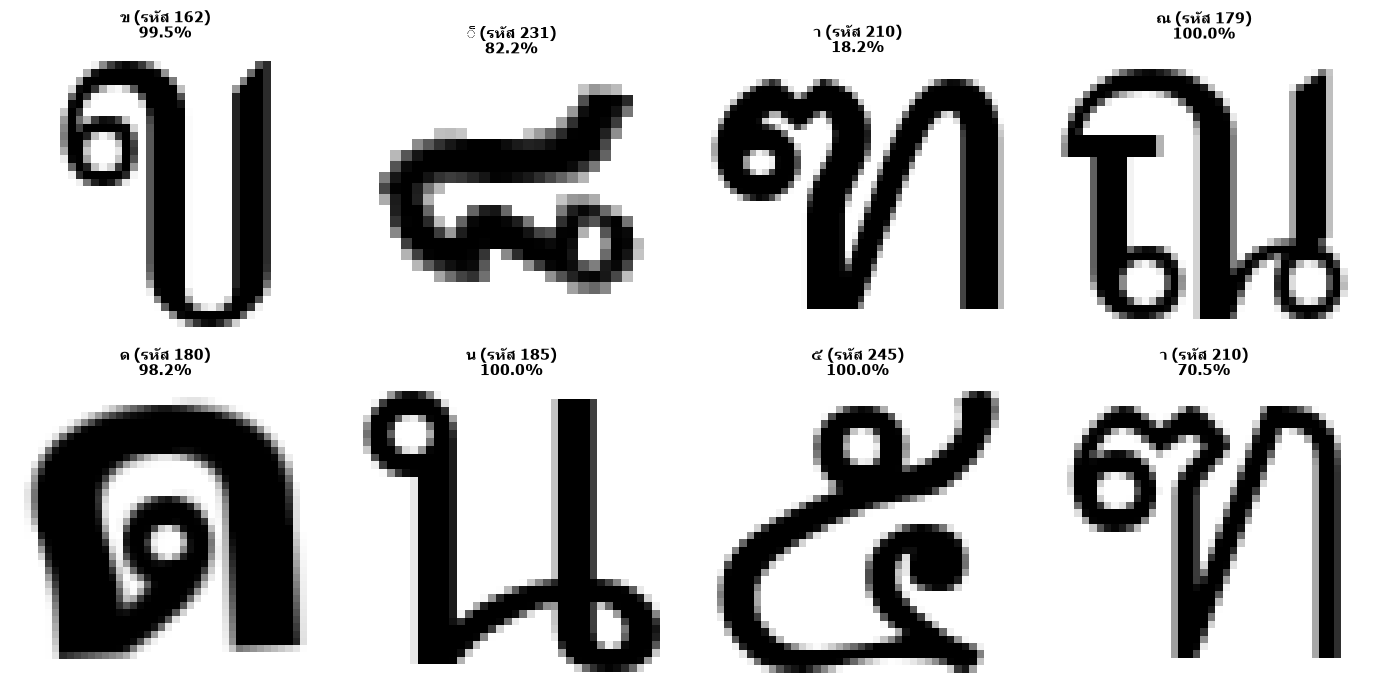

In [5]:
def show_demo(folder_path='test', n=8):
    if not os.path.exists(folder_path):
        print(f'ไม่พบโฟลเดอร์: {folder_path}')
        return
        
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff', '.tif', '.gif')
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)]
    if not files:
        print(f'ไม่พบรูปภาพใน: {folder_path}')
        return
        
    import random
    sample_files = random.sample(files, min(n, len(files)))
    
    cols = 4
    rows = int(np.ceil(len(sample_files) / cols))
    plt.figure(figsize=(cols * 3.5, rows * 3.5))
    
    for i, fp in enumerate(sample_files):
        res = predict_image(fp, show=False)
        img = load_image(fp)
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{res['char']} (รหัส {res['code']})\n{res['confidence']:.1f}%", fontsize=11, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# เรียกแสดงตัวอย่างการทำนาย
if os.path.exists('test'):
    show_demo('test', n=8)
